# VWB 3x vs latest `pump_dump_combined`

Correlation and portfolio test between:

- current `volume_weighted_breakout` champion, with bar returns scaled to `3x`;
- latest corrected `notebooks/pump_dump_combined` stream from `15_2_kelly_walkforward`: rollover/catastrophe-stop book, WF entry filter, realistic DCA engine with capacity/slippage, and walk-forward per-leg sizing.

Period is aligned to `2024-01-01 -> 2026-01-01`; no 2026 holdout/future months are used in this comparison.

In [1]:
from pathlib import Path
import sys, heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from sklearn.ensemble import HistGradientBoostingRegressor
from IPython.display import display

HERE = Path.cwd()
if HERE.name == "volume_weighted_breakout":
    NB_DIR = HERE
elif (HERE / "notebooks" / "volume_weighted_breakout").exists():
    NB_DIR = HERE / "notebooks" / "volume_weighted_breakout"
else:
    NB_DIR = Path(".").resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from _lab import strategy, run_pair, drawdown

ROOT = NB_DIR.parents[1]
PD_DIR = ROOT / "notebooks" / "pump_dump_combined"
PERIOD_START = "2024-01-01"
PERIOD_END = "2026-01-01"
INITIAL_CASH = 1000.0
VWB_LEVERAGE = 3.0
PUMP_PARQUET = PD_DIR / "_out" / "pump_rollover_visible.parquet"
DUMP_PARQUET = PD_DIR / "_out" / "dump_rollover_visible.parquet"

plt.style.use("seaborn-v0_8-darkgrid")
print("repo:", ROOT)
print("pump:", PUMP_PARQUET, PUMP_PARQUET.exists())
print("dump:", DUMP_PARQUET, DUMP_PARQUET.exists())

repo: C:\Users\digbi\Projects\research-lab
pump: C:\Users\digbi\Projects\research-lab\notebooks\pump_dump_combined\_out\pump_rollover_visible.parquet True
dump: C:\Users\digbi\Projects\research-lab\notebooks\pump_dump_combined\_out\dump_rollover_visible.parquet True


## Build latest combined pump/dump stream

This mirrors `notebooks/pump_dump_combined/15_2_kelly_walkforward.ipynb`, but reads the visible-period caches rebuilt for `2024-01-01 -> 2026-01-01`.

In [2]:
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]
PUMP_G, DUMP_G = 6, 6
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]

def naive(s):
    s = pd.to_datetime(s)
    return s.dt.tz_localize(None) if s.dt.tz is not None else s

def wf_filter(df, feats, label):
    pred=np.full(len(df),np.nan)
    cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]
    prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats])
        prev=cut
    return df[(pred>0)|np.isnan(pred)]

PUMP = pd.read_parquet(PUMP_PARQUET)
DUMP = pd.read_parquet(DUMP_PARQUET)
for D in (PUMP,DUMP):
    D["entry"] = naive(D["entry"])
    for i in range(len(GIVEBACKS)):
        D[f"exit{i}"] = naive(D[f"exit{i}"])

pk = wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]), PF, "pnl")
dk = wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]), DF, "pnl")
NEW = pd.concat([
    pk[["sym","entry","exit_ts","pnl","liq","stream"]],
    dk[["sym","entry","exit_ts","pnl","liq","stream"]],
]).sort_values("entry").reset_index(drop=True)

print(f"combined book: {len(NEW)} trades; pump {(NEW.stream=='pump').sum()} / dump {(NEW.stream=='dump').sum()}")
print(f"span: {NEW.entry.min()} -> {NEW.entry.max()}")
display(NEW.groupby("stream").pnl.agg(['count','mean','median','std','min','max']))

combined book: 4402 trades; pump 2893 / dump 1509
span: 2024-01-02 16:52:00 -> 2025-12-31 10:50:00


,count,mean,median,std,min,max
stream,,,,,,
dump,1509,0.055920,0.043676,0.144675,-0.330668,1.161944
pump,2893,-0.004022,0.001697,0.075875,-0.359391,0.590397


In [3]:
def run_engine_perleg(df,f_pump,f_dump,n_slots=50,reserve=0.10,cap_frac=0.10,cap_minutes=30,impact=True,start=1000.0):
    eq=start; cash=eq; openp=[]; ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; liqs=df.liq.values; strm=df.stream.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        f=f_pump if strm[i]=="pump" else f_dump
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0.0,avail),cash)
        if cap_frac is not None: no=min(no,cap_frac*liqs[i]*cap_minutes)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02,0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec],index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    return dict(sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan)

FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10
def run_dca(df, ffrac=None, f_pump=0.05, f_dump=0.05, start=1000., monthly=200., reserve=0.10, MAX=18, cap=True, slipmodel=True):
    df=df.sort_values("entry").reset_index(drop=True)
    en=df.entry.values.astype("datetime64[ns]"); ex=df.exit_ts.values.astype("datetime64[ns]")
    bpnl=df.pnl.values; liq=df.liq.values; stream=df.stream.values
    cap_no=PART_CAP*liq*FILL_MIN
    months=pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1), pd.Timestamp(ex.max()), freq="MS")
    cash=start; contrib=start; dep=0.; units=start; openh=[]; mi=0
    nav_t=[pd.Timestamp(en.min())]; nav_v=[1.0]; cf=[(-start,pd.Timestamp(en.min()))]
    taken=0; capped=0; slip=0.; trec=[]
    def snap(t):
        eq=cash+dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now:
            eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly; cf.append((-monthly,months[mi])); snap(months[mi]); mi+=1
        while openh and openh[0][0]<=en[i]:
            xt,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; snap(xt)
        eq=cash+dep
        f=ffrac[i] if ffrac is not None else (f_pump if stream[i]=="pump" else f_dump)
        desired=f*eq; no=min(desired,cap_no[i]) if cap else desired
        if cap and no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=(SPREAD+IMPACT*part) if slipmodel else 0.0; slip+=no*sl
            cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,bpnl[i]-sl,stream[i])); taken+=1; trec.append((bpnl[i]-sl,no,stream[i])); snap(en[i])
    while mi<len(months):
        eq=cash+dep; nav=eq/units; units+=200./nav; cash+=200.; contrib+=200.; cf.append((-200.,months[mi])); mi+=1
    for xt,no,pn,st in sorted(openh): cash+=no*(1+pn); dep-=no; snap(xt)
    final=cash+dep; cf.append((final,pd.Timestamp(ex.max())))
    nav=pd.Series(nav_v,index=pd.to_datetime(nav_t)).sort_index()
    nav=nav[~nav.index.duplicated(keep="last")].resample("1D").last().ffill()
    tk=pd.DataFrame(trec,columns=["pnl","notional","stream"]); tk["usd"]=tk.notional*tk.pnl
    return dict(final=final,contrib=contrib,nav=nav,taken=taken,capped=capped,slip=slip,tk=tk,cf=cf)

def xirr(cf):
    amts=np.array([a for a,_ in cf]); ds=pd.to_datetime([d for _,d in cf]); t=np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t),-0.999,100)
    except Exception: return np.nan

def perf_stats(returns, equity=None, periods=365):
    r=returns.dropna()
    if equity is None: equity=INITIAL_CASH*(1+r).cumprod()
    years=max((equity.index[-1]-equity.index[0]).days/365.25,1e-9)
    total=equity.iloc[-1]/equity.iloc[0]-1
    cagr=(equity.iloc[-1]/equity.iloc[0])**(1/years)-1
    sh=np.nan if r.std()==0 else r.mean()/r.std()*np.sqrt(periods)
    dd=equity/equity.cummax()-1
    return dict(end_equity=equity.iloc[-1], total_return=total, cagr=cagr, ann_vol=r.std()*np.sqrt(periods), sharpe=sh, max_dd=dd.min(), calmar=np.nan if dd.min()==0 else cagr/abs(dd.min()), worst_day=r.min(), best_day=r.max())
print("engines ready")

engines ready


## Walk-forward per-leg sizing from latest notebook

In [4]:
FPg=[0.02,0.03,0.05,0.08,0.10,0.12,0.15]
FDg=[0.02,0.03,0.05,0.08]
cuts=[int(len(NEW)*q) for q in (0.40,0.55,0.70,0.85,1.0)]
ffwf=np.full(len(NEW),0.05)
schedule=[]; prev=cuts[0]
for cut in cuts[1:]:
    trail=NEW.iloc[:prev]; best=None
    for fp in FPg:
        for fd in FDg:
            s=run_engine_perleg(trail,fp,fd)["sharpe"]
            if best is None or s>best[0]: best=(s,fp,fd)
    _,fp,fd=best
    schedule.append((prev,cut,fp,fd))
    strm=NEW.stream.values[prev:cut]
    ffwf[prev:cut]=np.where(strm=="pump",fp,fd)
    prev=cut

print("WF per-leg schedule:")
for a,b,fp,fd in schedule:
    print(f"  {NEW.entry.iloc[a].date()}..{NEW.entry.iloc[b-1].date()}: pump {fp:.0%} / dump {fd:.0%}")

R_pd = run_dca(NEW, ffrac=ffwf)
pd_nav = R_pd["nav"].loc[PERIOD_START:PERIOD_END]
pd_equity = INITIAL_CASH * pd_nav / pd_nav.iloc[0]
print(f"latest PD NAV: final cash ${R_pd['final']:,.0f}, contributed ${R_pd['contrib']:,.0f}, taken {R_pd['taken']}, capped {R_pd['capped']}")
print(f"NAV equity rebased: ${pd_equity.iloc[0]:.2f} -> ${pd_equity.iloc[-1]:.2f}")

WF per-leg schedule:
  2024-11-11..2025-01-08: pump 5% / dump 8%
  2025-01-08..2025-06-29: pump 2% / dump 8%
  2025-06-29..2025-10-10: pump 10% / dump 8%
  2025-10-10..2025-12-31: pump 2% / dump 8%
latest PD NAV: final cash $15,532, contributed $5,800, taken 3269, capped 126
NAV equity rebased: $1000.00 -> $4114.01


## VWB 3x and aligned daily returns

In [5]:
res_vwb = run_pair(strategy.DEFAULT_SYMBOLS, start=PERIOD_START, end=PERIOD_END)
vwb_eq = res_vwb["curves"]["equity"].copy()
vwb_eq.index = pd.to_datetime(vwb_eq.index, utc=True).tz_convert(None)
vwb_ret_bar = vwb_eq.pct_change().fillna(0.0)
vwb_ret_bar_3x = (VWB_LEVERAGE * vwb_ret_bar).clip(lower=-0.999)
vwb_eq_3x = INITIAL_CASH * (1.0 + vwb_ret_bar_3x).cumprod()

daily = pd.DataFrame({
    "vwb_3x_equity": vwb_eq_3x.resample("1D").last(),
    "pump_dump_latest_equity": pd_equity.resample("1D").last(),
}).dropna()
daily_ret = daily.pct_change().dropna()
daily_ret.columns = ["vwb_3x", "pump_dump_latest"]

display(daily.head())
display(daily.tail())
print("Common daily observations:", len(daily_ret))

,vwb_3x_equity,pump_dump_latest_equity
2024-01-01,1000.0,1000.000000
2024-01-02,1000.0,999.810860
2024-01-03,1000.0,1136.105570
2024-01-04,1000.0,1134.460553
2024-01-05,1000.0,1133.826624


,vwb_3x_equity,pump_dump_latest_equity
2025-12-27,7889.349027,4161.933527
2025-12-28,7889.349027,4162.974466
2025-12-29,7358.715221,4135.025060
2025-12-30,7358.715221,4152.991652
2025-12-31,7358.715221,4114.009008


Common daily observations: 730


In [6]:
stats = pd.DataFrame({
    "vwb_3x": perf_stats(daily_ret["vwb_3x"], daily["vwb_3x_equity"]),
    "pump_dump_latest": perf_stats(daily_ret["pump_dump_latest"], daily["pump_dump_latest_equity"]),
}).T
display(stats)
pearson = daily_ret["vwb_3x"].corr(daily_ret["pump_dump_latest"], method="pearson")
spearman = daily_ret["vwb_3x"].corr(daily_ret["pump_dump_latest"], method="spearman")
print(f"Pearson daily correlation: {pearson:.4f}")
print(f"Spearman daily correlation: {spearman:.4f}")

,end_equity,total_return,cagr,ann_vol,sharpe,max_dd,calmar,worst_day,best_day
vwb_3x,7358.715221,6.358715,1.714550,0.622186,1.908845,-0.270479,6.338936,-0.126569,0.247798
pump_dump_latest,4114.009008,3.114009,1.029285,0.426956,1.854172,-0.266211,3.866428,-0.126634,0.383507


Pearson daily correlation: -0.0709
Spearman daily correlation: 0.0141


## Correlation charts

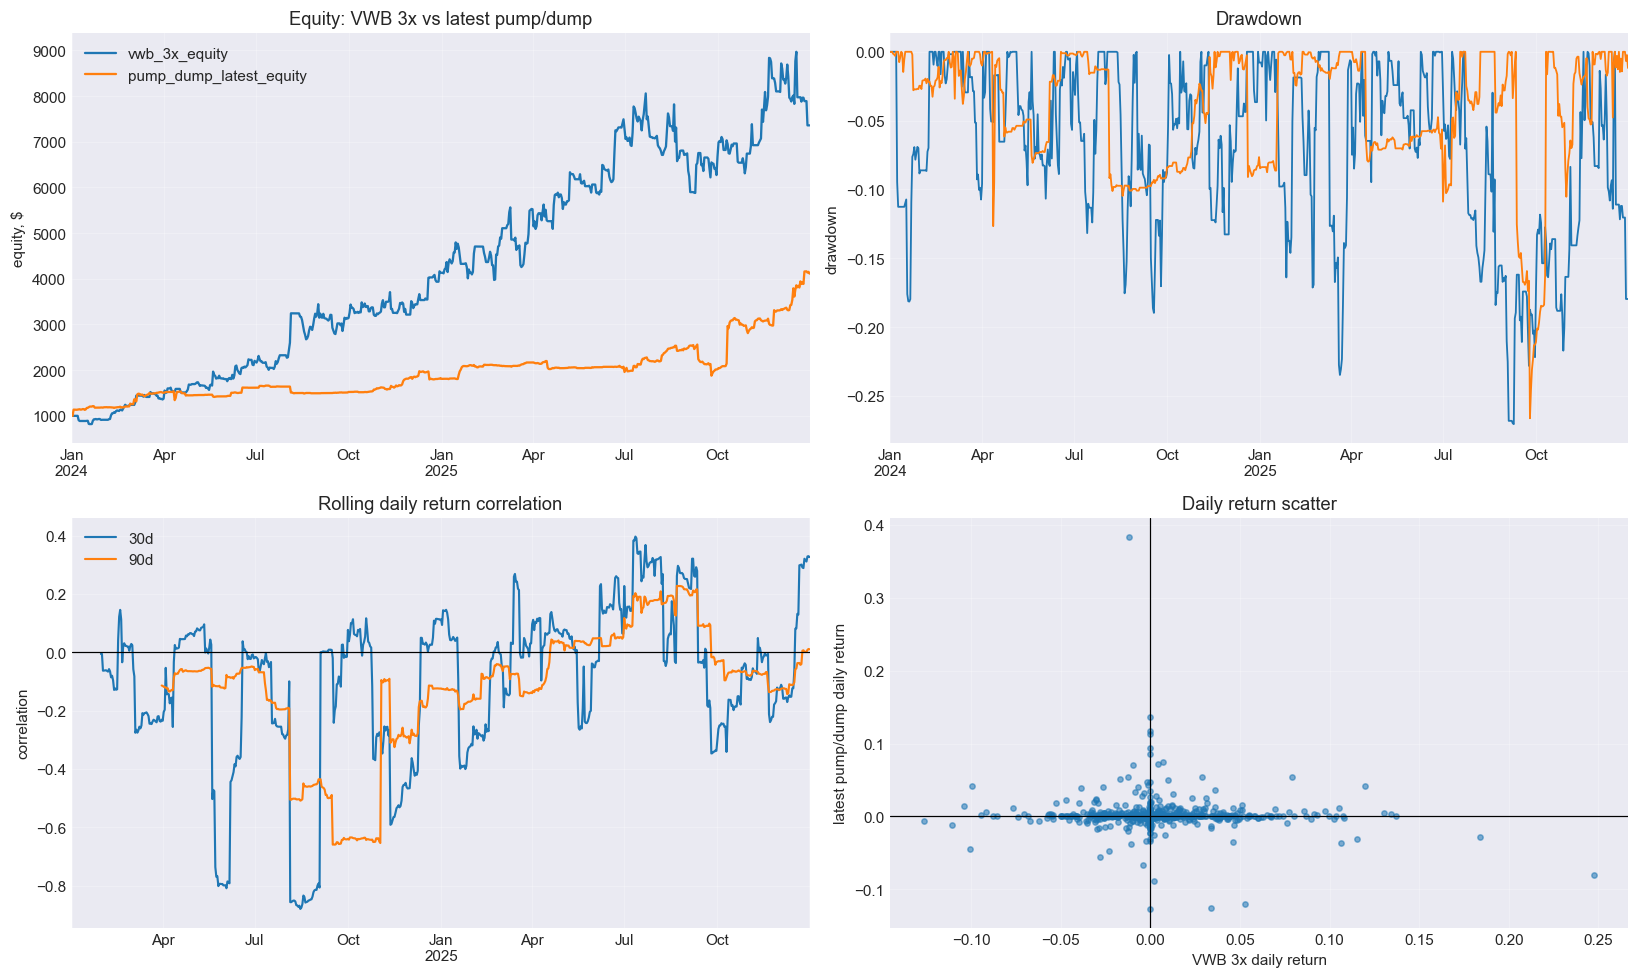

In [7]:
rolling = pd.DataFrame({
    "30d": daily_ret["vwb_3x"].rolling(30).corr(daily_ret["pump_dump_latest"]),
    "90d": daily_ret["vwb_3x"].rolling(90).corr(daily_ret["pump_dump_latest"]),
})
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
(daily / daily.iloc[0] * INITIAL_CASH).plot(ax=axes[0, 0], lw=1.5)
axes[0, 0].set_title("Equity: VWB 3x vs latest pump/dump")
axes[0, 0].set_ylabel("equity, $")
drawdown(daily["vwb_3x_equity"]).rename("VWB 3x").plot(ax=axes[0, 1], lw=1.2)
drawdown(daily["pump_dump_latest_equity"]).rename("latest pump/dump").plot(ax=axes[0, 1], lw=1.2)
axes[0, 1].set_title("Drawdown")
axes[0, 1].set_ylabel("drawdown")
rolling.plot(ax=axes[1, 0], lw=1.4)
axes[1, 0].axhline(0, color="black", lw=0.8)
axes[1, 0].set_title("Rolling daily return correlation")
axes[1, 0].set_ylabel("correlation")
axes[1, 1].scatter(daily_ret["vwb_3x"], daily_ret["pump_dump_latest"], s=12, alpha=0.55)
axes[1, 1].axhline(0, color="black", lw=0.8); axes[1, 1].axvline(0, color="black", lw=0.8)
axes[1, 1].set_title("Daily return scatter")
axes[1, 1].set_xlabel("VWB 3x daily return")
axes[1, 1].set_ylabel("latest pump/dump daily return")
plt.tight_layout()

## Portfolio test

Daily-rebalanced synthetic mix: `portfolio_return = w * VWB_3x + (1-w) * latest_pump_dump_NAV_return`.

In [8]:
weights=np.round(np.arange(0,1.0001,0.05),2)
rows=[]; port_equities={}
for w in weights:
    r=w*daily_ret["vwb_3x"] + (1-w)*daily_ret["pump_dump_latest"]
    eq=INITIAL_CASH*(1+r).cumprod()
    port_equities[f"{int(w*100):03d}% VWB"] = eq
    row=perf_stats(r,eq); row["vwb_weight"]=w; row["pump_dump_weight"]=1-w; rows.append(row)
portfolio=pd.DataFrame(rows).set_index("vwb_weight")
display(portfolio[["pump_dump_weight","end_equity","total_return","cagr","ann_vol","sharpe","max_dd","calmar","worst_day"]])
best_sharpe_w=portfolio["sharpe"].idxmax(); best_calmar_w=portfolio["calmar"].idxmax(); min_dd_w=portfolio["max_dd"].idxmax()
print(f"Best Sharpe weight: {best_sharpe_w:.0%} VWB / {1-best_sharpe_w:.0%} pump_dump")
print(f"Best Calmar weight: {best_calmar_w:.0%} VWB / {1-best_calmar_w:.0%} pump_dump")
print(f"Lowest DD weight: {min_dd_w:.0%} VWB / {1-min_dd_w:.0%} pump_dump")

,pump_dump_weight,end_equity,total_return,cagr,ann_vol,sharpe,max_dd,calmar,worst_day
vwb_weight,,,,,,,,,
0.00,1.00,4114.009008,3.114787,1.031448,0.426956,1.854172,-0.266211,3.874554,-0.126634
0.05,0.95,4351.864201,3.352646,1.089459,0.404594,2.005590,-0.253416,4.299092,-0.120327
0.10,0.90,4590.120923,3.590902,1.146001,0.384886,2.159734,-0.241361,4.748078,-0.114020
0.15,0.85,4827.444118,3.828220,1.200883,0.368257,2.311027,-0.232826,5.157866,-0.107712
0.20,0.80,5062.439376,4.063206,1.253915,0.355140,2.452138,-0.225170,5.568750,-0.101405
0.25,0.75,5293.665185,4.294416,1.304909,0.345935,2.574624,-0.219814,5.936416,-0.095098
0.30,0.70,5519.646360,4.520377,1.353682,0.340959,2.670271,-0.214642,6.306701,-0.088791
0.35,0.65,5738.888494,4.739594,1.400056,0.340397,2.732845,-0.209655,6.677908,-0.082484
0.40,0.60,5949.893249,4.950569,1.443859,0.344272,2.759602,-0.204855,7.048187,-0.076176


Best Sharpe weight: 40% VWB / 60% pump_dump
Best Calmar weight: 70% VWB / 30% pump_dump
Lowest DD weight: 65% VWB / 35% pump_dump


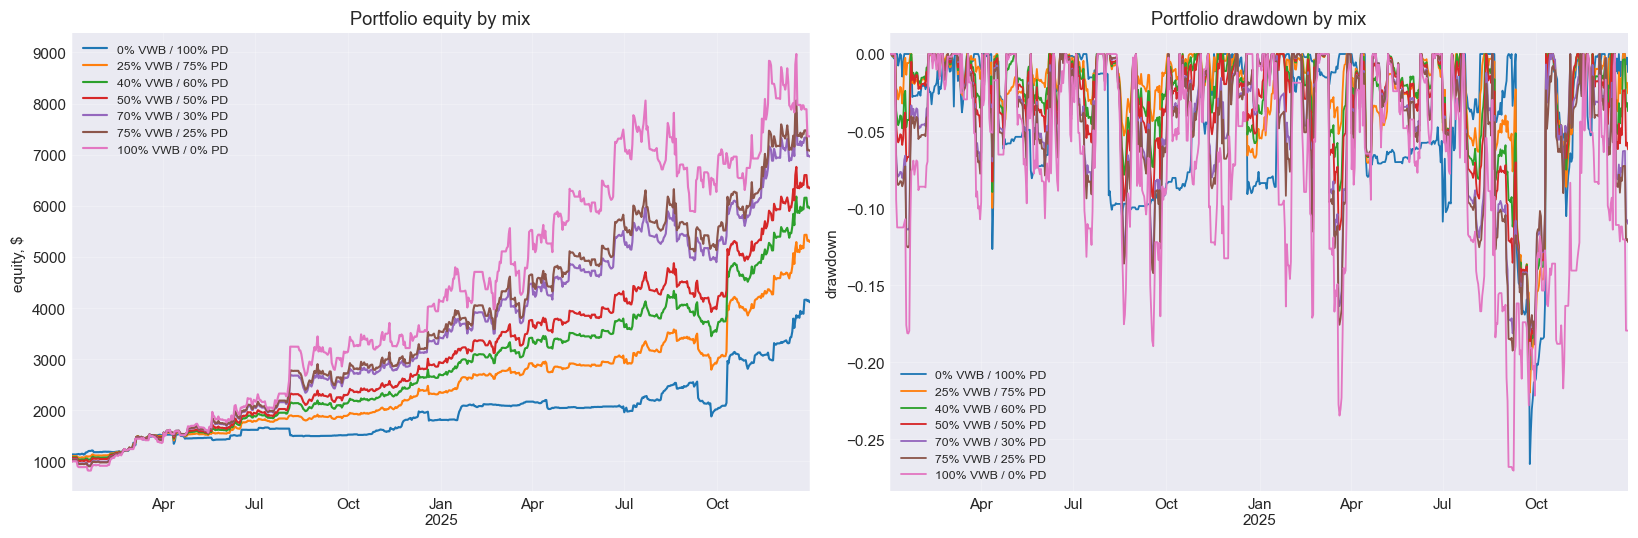

In [9]:
selected_weights=sorted(set([0.0,0.25,0.5,0.75,1.0,float(best_sharpe_w),float(best_calmar_w)]))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for w in selected_weights:
    label=f"{int(round(w*100))}% VWB / {int(round((1-w)*100))}% PD"
    eq=port_equities[f"{int(round(w*100)):03d}% VWB"]
    eq.plot(ax=axes[0], label=label, lw=1.4)
    drawdown(eq).plot(ax=axes[1], label=label, lw=1.2)
axes[0].set_title("Portfolio equity by mix"); axes[0].set_ylabel("equity, $"); axes[0].legend(fontsize=8)
axes[1].set_title("Portfolio drawdown by mix"); axes[1].set_ylabel("drawdown"); axes[1].legend(fontsize=8)
plt.tight_layout()

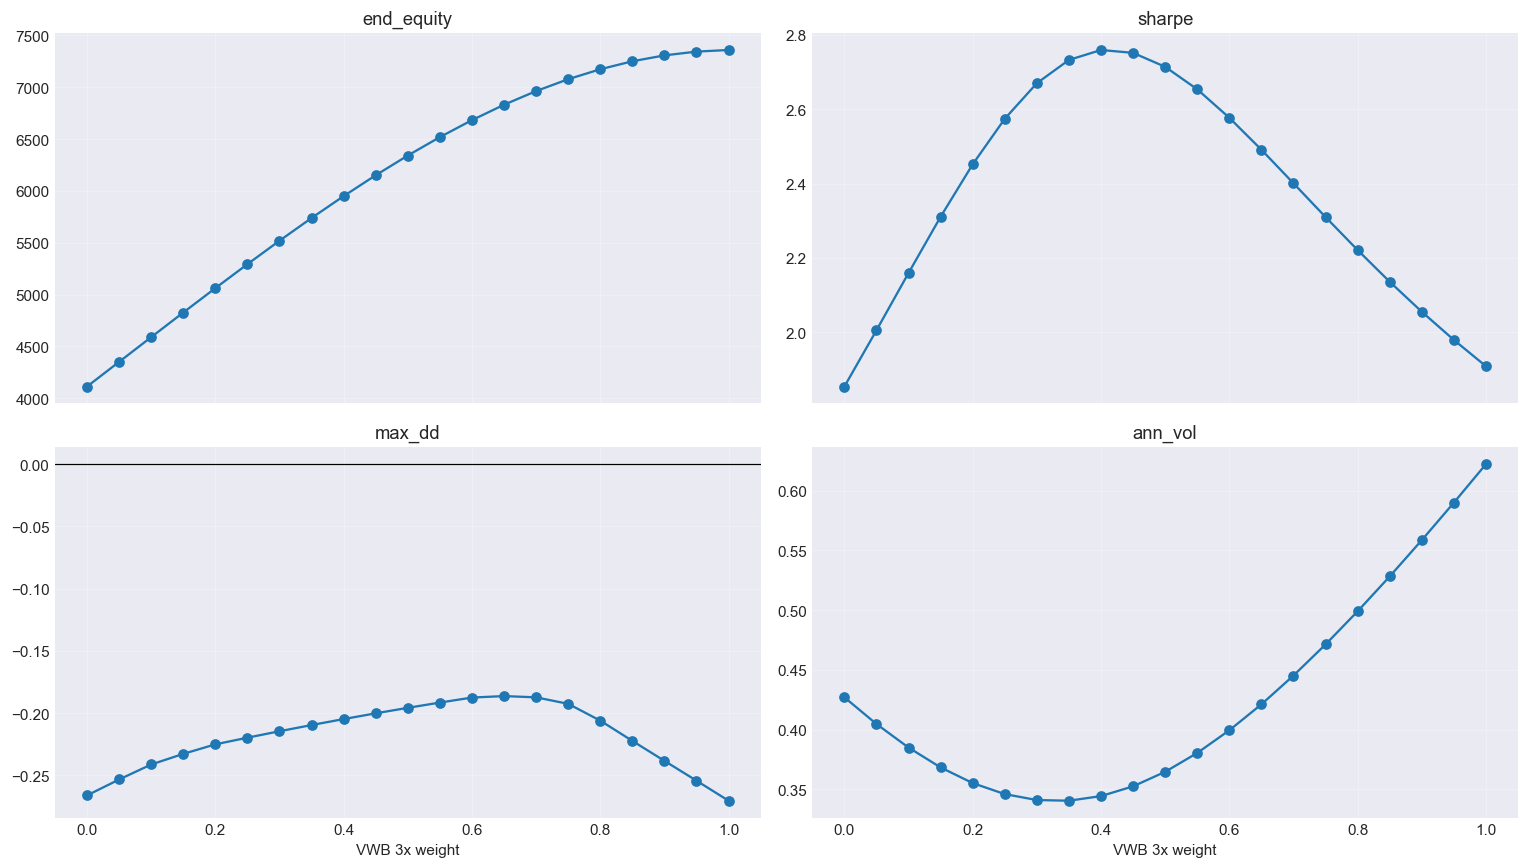

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, metric in zip(axes.ravel(), ["end_equity","sharpe","max_dd","ann_vol"]):
    portfolio[metric].plot(ax=ax, marker="o")
    ax.set_title(metric); ax.set_xlabel("VWB 3x weight")
    if metric == "max_dd": ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()